# KF7032 ASSESSMENT

# Introduction
Violence is a leading cause of death for both teenagers and adults in the UK and the world at large [1]. Violent crimes encompasses burglary, robbery, possession of firearms, knives and other substances like acid, aggravated assault, homicide and so on. These crimes are majorly perpetrated by youths and juveniles in the society [2] and research has shown that violent crime patterns are closely related to socio-economic deprivation [3,4], geographical location [5] and drug use [6]. The presence of large crime datasets now gives room for the empirical investigation of several trends and theories through data-driven approaches.

There were a number of assertions in a televised documentary, Ross Kemp and the Armed Police (ITV, 2018) about a pattern in the crime rates in the UK, such as that burglary has been on the rise, that there have been more cases of firearms offences in Liverpool compared to other areas, and that the drug crime is linked to firearms offences. Such allegations should be systematically tested on official data about crime and not on hearsay. The development of distributed computing systems like Apache Spark allows processing geographically detailed, large datasets with high efficiency, which cannot be processed with conventional tools.

The main objective of this project is to evaluate the validity of the assertions made in the documentary by analyzing publicly available UK crime statistics. To achieve this, the project uses Apache Spark on an Infrastructure as a Service (IaaS) platform via the cloud to handle massive amounts of crime data effectively. The analysis includes the process of filtering the corresponding categories of crime, converting the data to time-series formats and carrying out aggregations and comparisons, backed by few visualisations. Throughout, diagnostic checks are made to confirm the integrity of data and processing before making conclusions about each claim.

# 2) Component Selection and Data Pipeline Implementation code 10 Marks


In [2]:
# Importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions
from pyspark.sql.functions import col, count, when, regexp_replace
from pyspark.sql import SparkSession
from pyspark.sql.types import *

In [3]:
# Creating Spark Session
spark = (SparkSession.builder
         .appName("W23052320 KF7032 ASSESSMENT") 
         .master("local[*]")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
# Validating Spark Session
spark

# Loading the full crime dataset
crime_df = spark.read.csv(
    "all_crimes21_hdr.txt.gz",
    header = True,
    inferSchema = True
)

# Inspecting the data and schema
crime_df.show(5)
crime_df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/22 12:07:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

+--------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+--------------------+--------------------+---------------------+-------+
|Crime ID|              Month|         Reported by|        Falls within|Longitude| Latitude|            Location|LSOA code|           LSOA name|          Crime type|Last outcome category|Context|
+--------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+--------------------+--------------------+---------------------+-------+
|    NULL|2010-12-01 00:00:00|Avon and Somerset...|Avon and Somerset...|  -0.8056|51.819143|On or near Norfol...|E01017662| Aylesbury Vale 015C|         Other crime|                 NULL|   NULL|
|    NULL|2010-12-01 00:00:00|Avon and Somerset...|Avon and Somerset...|-2.494366|51.418169|On or near Keynsh...|E01014399|Bath and North Ea...|Anti-social behav...|                 NULL|   NULL|
|    NULL|2010-12-01

In [4]:
# Load dataset containing population data 
lsoa_pop_df = spark.read.csv(
    "LSOA_pop_v2.csv",
    header = True,
    inferSchema = True)

lsoa_pop_df.show(2)

+----+---------------+--------------+-----------+----------------------------------------------+--------------------------------+----------------------------------+-----------------------------------------------+------------------------------------------------------------+----------------------------------------------------------------------------------------------------------+------------------------------------------+------------------------------------------------------------------+
|date|      geography|geography code|Rural Urban|Variable: All usual residents; measures: Value|Variable: Males; measures: Value|Variable: Females; measures: Value|Variable: Lives in a household; measures: Value|Variable: Lives in a communal establishment; measures: Value|Variable: Schoolchild or full-time student aged 4 and over at their non term-time address; measures: Value|Variable: Area (Hectares); measures: Value|Variable: Density (number of persons per hectare); measures: Value|
+----+------------

# 3) Data Extraction and Filtering ... code, 10 Marks


In [5]:
# Checking for null values

crime_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in crime_df.columns
]).show()

[Stage 6:>                                                          (0 + 1) / 1]

+--------+-----+-----------+------------+---------+--------+--------+---------+---------+----------+---------------------+--------+
|Crime ID|Month|Reported by|Falls within|Longitude|Latitude|Location|LSOA code|LSOA name|Crime type|Last outcome category| Context|
+--------+-----+-----------+------------+---------+--------+--------+---------+---------+----------+---------------------+--------+
|24242335|    0|          0|           0|   957447|  957447|       0|  2528265|  2528265|         0|             26418132|64955845|
+--------+-----+-----------+------------+---------+--------+--------+---------+---------+----------+---------------------+--------+



In [6]:
# Grouping the data by the type of crime committed and showing the count
crime_df.groupBy(col("Crime type")).count() \
    .orderBy(col("count").desc()) \
    .show(truncate = False)

[Stage 9:>                                                          (0 + 1) / 1]

+----------------------------+--------+
|Crime type                  |count   |
+----------------------------+--------+
|Anti-social behaviour       |20211528|
|Violence and sexual offences|11411540|
|Criminal damage and arson   |5343182 |
|Other theft                 |5206259 |
|Burglary                    |4350252 |
|Vehicle crime               |4170769 |
|Shoplifting                 |3227557 |
|Other crime                 |2565111 |
|Public order                |2564695 |
|Drugs                       |1682486 |
|Violent crime               |1673219 |
|Bicycle theft               |735689  |
|Theft from the person       |714621  |
|Robbery                     |696008  |
|Possession of weapons       |283189  |
|Public disorder and weapons |242145  |
+----------------------------+--------+



In [7]:
# Filtering dataset to show only the relevant crimes 
relevant_df = crime_df.filter(
    (crime_df["Crime type"] == "Burglary") |
    (crime_df["Crime type"] == "Drugs") |
    (crime_df["Crime type"] == "Possession of weapons") 
)
# Show five records in the dataframe
relevant_df.show(5)

+--------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+--------------------+----------+---------------------+-------+
|Crime ID|              Month|         Reported by|        Falls within|Longitude| Latitude|            Location|LSOA code|           LSOA name|Crime type|Last outcome category|Context|
+--------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+--------------------+----------+---------------------+-------+
|    NULL|2010-12-01 00:00:00|Avon and Somerset...|Avon and Somerset...|-2.513308|51.409456|On or near Charlt...|E01014399|Bath and North Ea...|  Burglary|                 NULL|   NULL|
|    NULL|2010-12-01 00:00:00|Avon and Somerset...|Avon and Somerset...|-2.509126|51.416137|On or near St. Fr...|E01014399|Bath and North Ea...|  Burglary|                 NULL|   NULL|
|    NULL|2010-12-01 00:00:00|Avon and Somerset...|Avon and Somerset..

In [8]:
# Checking the dataframe to show if relevant crimes properly filtered
relevant_df.groupBy("Crime type").count().show(truncate=False)

[Stage 13:>                                                         (0 + 1) / 1]

+---------------------+-------+
|Crime type           |count  |
+---------------------+-------+
|Drugs                |1682486|
|Burglary             |4350252|
|Possession of weapons|283189 |
+---------------------+-------+



# 4) Design, Development and reasoning behind use of multiple visualization methods, statistics, and machine learning Models, markdown, code, markdown, 20 Marks
## CLAIM 1 - BURGLARY TREND OVER TIME 

This section examines the claim of whether the crime of burglary has grown with time. A time series was used to visualize the variations in the frequency of crime every month from December 2010 to May 2021. 
The approach used first was aggregating the burglary incidences at the monthly level, which minimizes the short-term variations in the crime data on a daily basis and allows long term trends to be observed much more clearly. This monthly aggregation is also consistent with how the dataset is organised leading to consistent analysis throughout. 
After aggregating, a line plot was used to visualize the time series. Line plots are said to be the best choice for visualizing time series data [7]. The rolling mean is calculated and added to the visualization to help improve interpretability, reveal long term trends and reduce the noise in the data [8]. 


In [9]:
# Checking the timerange in the dataset to be used to build the timeseries 
relevant_df.selectExpr(
    "min(Month) as min_month",
    "max(Month) as max_month"
).show(truncate=False)


[Stage 16:>                                                         (0 + 1) / 1]

+-------------------+-------------------+
|min_month          |max_month          |
+-------------------+-------------------+
|2010-12-01 00:00:00|2021-05-01 00:00:00|
+-------------------+-------------------+



In [10]:
# Building the Timeseries for burglary crime over several months from 2010 to 2021
ts_burglary = (
    crime_df
    .filter(crime_df["Crime type"] == "Burglary")
    .groupBy("Month")
    .count()
    .orderBy("Month")
)
ts_burglary.show(12, truncate=False)

[Stage 19:>                                                         (0 + 1) / 1]

+-------------------+-----+
|Month              |count|
+-------------------+-----+
|2010-12-01 00:00:00|37893|
|2011-01-01 00:00:00|44388|
|2011-02-01 00:00:00|41821|
|2011-03-01 00:00:00|43777|
|2011-04-01 00:00:00|40062|
|2011-05-01 00:00:00|43120|
|2011-06-01 00:00:00|40004|
|2011-07-01 00:00:00|40404|
|2011-08-01 00:00:00|41893|
|2011-09-01 00:00:00|40587|
|2011-10-01 00:00:00|42311|
|2011-11-01 00:00:00|44850|
+-------------------+-----+
only showing top 12 rows


In [11]:
# Converting the grouped data to pandas dataframe 
burglary_ts_pd = ts_burglary.toPandas()
burglary_ts_pd.head()

,Month,count
0,2010-12-01,37893
1,2011-01-01,44388
2,2011-02-01,41821
3,2011-03-01,43777
4,2011-04-01,40062


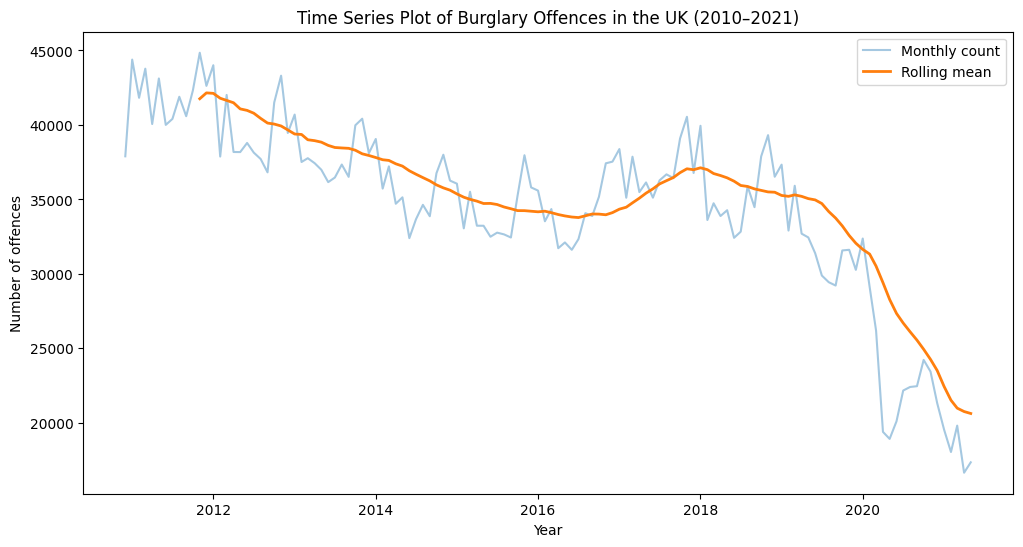

In [12]:
# Calculating the rolling mean to improve plot interpretability
burglary_ts_pd['rolling_12m'] = burglary_ts_pd['count'].rolling(window=12).mean()

# Plotting the timeseries for burglary crime
plt.figure(figsize=(12,6))
plt.plot(burglary_ts_pd['Month'], burglary_ts_pd['count'], alpha=0.4, label='Monthly count')
plt.plot(burglary_ts_pd['Month'], burglary_ts_pd['rolling_12m'], linewidth=2, label='Rolling mean')
plt.legend()
plt.title("Time Series Plot of Burglary Offences in the UK (2010–2021)")
plt.xlabel("Year")
plt.ylabel("Number of offences")
plt.show()

PLOT INTERPRETATION

The plot shows some fluctuation in the number of cases of reported burglary on a monthly basis. Although this varies, the rolling mean shows there is an overall decreasing trend of the offences of burglary during the period of study.

The years between about 2010 and 2016 show a gradual decrease in the number of burglary offences, then relative stagnation and a slight rise around 2017-2018. After 2019, there is an apparent sharp decline in the number of burglary incidents, and the number of cases and the rolling mean decreased significantly. This suggests that there was a substantial shift in the pattern of burglary in this later age.
Generally, the rolling mean assists in clarifying the trend in the series because it minimizes short-term noise and it implies that there is no long-term trend of increased burglary offences over the entire time period provided.


## CLAIM 2 - FIREARM INCIDENTS PER HEAD BY CITY

The method used here is to answer the question of whether Liverpool has a higher number of firearm incidents per head than any other UK region. The data on crime is given as incidents at LSOA level in terms of LSOA code and LSOA name whereas the population data is given as the number of residents at the same level. To investigate the claim, both dataset are merged and the LSOA records are mapped to a city label by deleting the LSOA suffix, allowing aggregation and comparisons between cities. 
City population is calculated by first choosing distinct LSOA code entries and summing these up by city, this is done to avoid inflating the population. The total number of firearms per city is computed individually and then the two aggregates are joined with the calculation of incidents per head.
To facilitate an easy comparison across locations and to determine whether the city of Liverpool is the highest-ranked, a ranked horizontal bar chart including 30 largest cities by the number of incidents per head was plotted. 


In [13]:
# Determining whether there are more firearm incidents per head in liverpool than anywhere else in the UK

# Filtering the firearm incidents assuming the crime type "possession of weapons" with "offender sent to prison" outcome is a firearm incident 
fireinc_df = crime_df.filter(
    (crime_df["Crime type"] == "Possession of weapons") &
    (crime_df["Last outcome category"] == "Offender sent to prison")
)
fireinc_df.show(5)

# Counting the number of firearm incidents recorded
fireinc_df.count()

+--------------------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+------------+--------------------+---------------------+-------+
|            Crime ID|              Month|         Reported by|        Falls within|Longitude| Latitude|            Location|LSOA code|   LSOA name|          Crime type|Last outcome category|Context|
+--------------------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+------------+--------------------+---------------------+-------+
|0b3b9b6734d5d39e0...|2013-05-01 00:00:00|Avon and Somerset...|Avon and Somerset...|-2.595297|51.490694|On or near Wellin...|E01014636|Bristol 004D|Possession of wea...| Offender sent to ...|   NULL|
|847bb34d1477d850d...|2013-05-01 00:00:00|Avon and Somerset...|Avon and Somerset...| -2.51668|51.476465|On or near Briar ...|E01014629|Bristol 018D|Possession of wea...| Offender sent to ...|   NULL|


10416

In [14]:
# Rename column names to match the names in the fire incidents dataset
lsoa_pop_df_ = lsoa_pop_df.withColumnRenamed(
    'geography code', 'LSOA code').withColumnRenamed('Variable: All usual residents; measures: Value', 'Population')

# Joining firearms incident with population data using LSOA code
fireinc_pop_df = fireinc_df.join(
    lsoa_pop_df_,
    fireinc_df["LSOA code"] == lsoa_pop_df_ ["LSOA code"],
    how = "inner"
)
# Removing the duplicate LSOA column 
fireinc_pop_df = fireinc_pop_df.drop(lsoa_pop_df_["LSOA code"])

# Selecting the relevant columns to address the claim
firearm_pop = fireinc_pop_df.select(
    "LSOA code",
    "LSOA name",
    "Population"
)

# Dropping the LSOA suffix from the LSOA name to create city column
firearm_pop = firearm_pop.withColumn(
    "City",
    regexp_replace(firearm_pop["LSOA name"], " [A-Z0-9]+$", "")
)
firearm_pop.show(5)

[Stage 35:>                                                         (0 + 1) / 1]

+---------+------------+----------+-------+
|LSOA code|   LSOA name|Population|   City|
+---------+------------+----------+-------+
|E01014636|Bristol 004D|      1496|Bristol|
|E01014629|Bristol 018D|      1477|Bristol|
|E01014485|Bristol 023A|      1817|Bristol|
|E01014655|Bristol 055C|      2365|Bristol|
|E01014655|Bristol 055C|      2365|Bristol|
+---------+------------+----------+-------+
only showing top 5 rows


In [15]:
# Checking total crimes vs unique LSOA codes
total_crimes = firearm_pop.count()
unique_lsoas = firearm_pop.select("LSOA code").distinct().count()

print("Total firearms incidents:", total_crimes)
print("Unique LSOA codes:", unique_lsoas)

# Counting firearm incidents per city
firearms_city = (
    firearm_pop
    .groupBy("City")
    .count()        
    .withColumnRenamed("count", "Firearm incidents")                          
)
firearms_city.show(5, truncate=False)

# Counting each LSOA population 
from pyspark.sql import functions as func

pop_df = (
    firearm_pop
    .select("City", "LSOA code", "Population")
    .dropDuplicates(["LSOA code"])
    .groupBy("City")
    .agg(func.sum("Population").alias("City population"))
)
pop_df.show(5, truncate=False)

# Joining the incidents and city population tables
firearm_city = (
    firearms_city
    .join(pop_df, on="City", how="left")
)

firearm_city.show(5, truncate=False)

Total firearms incidents: 10122
Unique LSOA codes: 6179


+--------------+-----------------+
|City          |Firearm incidents|
+--------------+-----------------+
|Worcester     |37               |
|Charnwood     |12               |
|North Kesteven|4                |
|Epping Forest |9                |
|Arun          |14               |
+--------------+-----------------+
only showing top 5 rows


+--------------+---------------+
|City          |City population|
+--------------+---------------+
|Worcester     |31205          |
|Charnwood     |12057          |
|North Kesteven|6295           |
|Epping Forest |14100          |
|Waveney       |12588          |
+--------------+---------------+
only showing top 5 rows


[Stage 60:>                 (0 + 1) / 1][Stage 61:>                 (0 + 1) / 1]

+--------------+-----------------+---------------+
|City          |Firearm incidents|City population|
+--------------+-----------------+---------------+
|Worcester     |37               |31205          |
|Charnwood     |12               |12057          |
|North Kesteven|4                |6295           |
|Epping Forest |9                |14100          |
|Arun          |14               |18267          |
+--------------+-----------------+---------------+
only showing top 5 rows


In [16]:
# Calcuating firearm incidents per head
firearm_city = (
    firearm_city
    .withColumn("Incidents per head",
    firearm_city["Firearm incidents"] / firearm_city["City population"])
)

firearm_city.show(10, truncate=False)

[Stage 71:>                 (0 + 1) / 1][Stage 72:>                 (0 + 1) / 1]

+--------------+-----------------+---------------+---------------------+
|City          |Firearm incidents|City population|Incidents per head   |
+--------------+-----------------+---------------+---------------------+
|Worcester     |37               |31205          |0.0011857074186829035|
|Charnwood     |12               |12057          |9.952724558347848E-4 |
|North Kesteven|4                |6295           |6.354249404289118E-4 |
|Epping Forest |9                |14100          |6.382978723404255E-4 |
|Arun          |14               |18267          |7.664093720917501E-4 |
|Waveney       |14               |12588          |0.0011121703209405784|
|Stroud        |4                |5885           |6.796941376380628E-4 |
|Sedgemoor     |12               |13121          |9.145644386860757E-4 |
|New Forest    |5                |6483           |7.712478790683325E-4 |
|Maldon        |3                |5439           |5.515719801434088E-4 |
+--------------+-----------------+---------------+-

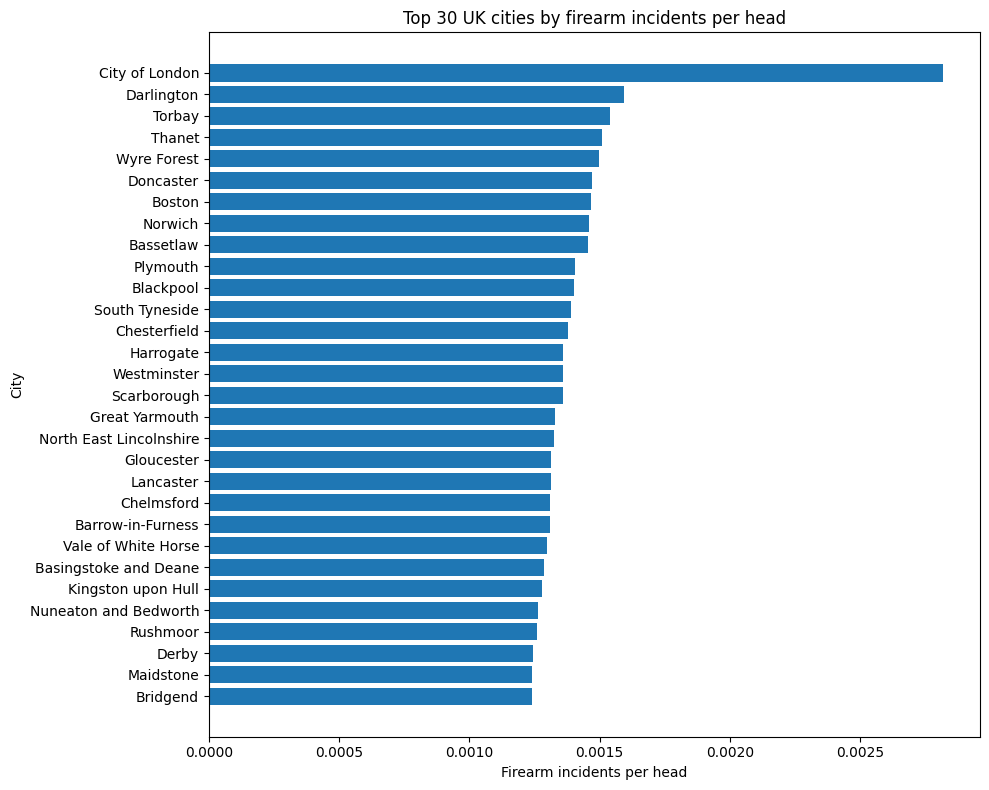

In [17]:
# Visualizing top 30 incidents per head 

# selecting the top 30 cities
perhead_30 = (
    firearm_city
    .orderBy(firearm_city["Incidents per head"].desc())
    .limit(30)
)

# Converting to pandas for visualization
perhead_30_pd = perhead_30.select("City", "Incidents per head").toPandas()
perhead_30_pd = perhead_30_pd.sort_values("Incidents per head")

# Visualizing top 30
plt.figure(figsize= (10,8))
plt.barh(perhead_30_pd["City"], perhead_30_pd["Incidents per head"])
plt.xlabel("Firearm incidents per head")
plt.ylabel("City")
plt.title("Top 30 UK cities by firearm incidents per head") 
plt.tight_layout()
plt.show()


PLOT INTERPRETATION

The bar chart depicts the 30 leading cities in the UK in terms of firearm incidence per head. In the City of London, the per-head rate is significantly higher than in other cities in the ranking. The other cities, lower down the list, constitute a much more closely-knit group, with the comparative differences between the rates per head of the cities being very small. This implies that the prevalence of firearm incidents per head is more or less the same in most cities.
The horizontal nature of the chart enables direct visual comparison of the cities and brings out the relative differences in the rate of firearm incidents when population has been normalised. Liverpool is not listed as one of the highest-ranked cities in this distribution, meaning that it has a lower per-head rate than the ones exhibited in the leading cities presented in the chart.


## CLAIM 3 - RELATIONSHIP BETWEEN FIREARM INCIDENTS AND DRUG OFFENCES

To examine the relationship between firearm incidents and drug offences, both crimes were aggregated on a monthly basis. This was done to minimize variations over short periods of time and to enable comparison on a similar time level. 
The main visualization tool that was chosen is the scatterplot since it is one of the most effective tools used to investigate possible associations between two quantitative variables [9]. It enables the direction, strength and the variability of any relationship to be graphically evaluated before performing actual statistical analysis.


In [18]:
# Determining whether firearm incidents are associated with drug offences

# Extracting drug offences 
drug_df = crime_df.filter(
    col("Crime type") == "Drugs"
)

drug_df.show(5)


[Stage 91:>                                                         (0 + 1) / 1]

+--------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+--------------------+----------+---------------------+-------+
|Crime ID|              Month|         Reported by|        Falls within|Longitude| Latitude|            Location|LSOA code|           LSOA name|Crime type|Last outcome category|Context|
+--------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+--------------------+----------+---------------------+-------+
|    NULL|2011-09-01 00:00:00|Avon and Somerset...|Avon and Somerset...|   -2.507|51.408557|On or near Tenby ...|E01014404|Bath and North Ea...|     Drugs|                 NULL|   NULL|
|    NULL|2011-09-01 00:00:00|Avon and Somerset...|Avon and Somerset...|-2.492186|51.413386|On or near Dragon...|E01014396|Bath and North Ea...|     Drugs|                 NULL|   NULL|
|    NULL|2011-09-01 00:00:00|Avon and Somerset...|Avon and Somerset..

In [19]:
# Aggregating firearm incidents by month & counting the incidents in every month
fireinc_month = (
    fireinc_df
    .groupBy("Month")
    .count()
    .withColumnRenamed("count", "Firearm incidents")
)
fireinc_month.show(3)

[Stage 92:>                                                         (0 + 1) / 1]

+-------------------+-----------------+
|              Month|Firearm incidents|
+-------------------+-----------------+
|2014-02-01 00:00:00|              121|
|2016-02-01 00:00:00|              169|
|2014-11-01 00:00:00|              123|
+-------------------+-----------------+
only showing top 3 rows


In [20]:
# Aggregating drug offences by month & cunting the drug offences in every month
drg_month = (
    drug_df
    .groupBy("Month")
    .count()
    .withColumnRenamed("count", "Drug offences")
)
drg_month.show(3)


[Stage 95:>                                                         (0 + 1) / 1]

+-------------------+-------------+
|              Month|Drug offences|
+-------------------+-------------+
|2019-12-01 00:00:00|        14168|
|2014-02-01 00:00:00|        14321|
|2016-02-01 00:00:00|        11323|
+-------------------+-------------+
only showing top 3 rows


In [21]:
# Joining both the drug offences and fire incidents table in ascending order by month

fire_drg_month = (
    fireinc_month
    .join(drg_month, on="Month", how="outer")
    .fillna(0)
    .orderBy("Month")
)

# Display the table 
fire_drg_month.show(10, truncate=False)


[Stage 98:>                                                         (0 + 1) / 1]

+-------------------+-----------------+-------------+
|Month              |Firearm incidents|Drug offences|
+-------------------+-----------------+-------------+
|2011-09-01 00:00:00|0                |16926        |
|2011-10-01 00:00:00|0                |18448        |
|2011-11-01 00:00:00|0                |18267        |
|2011-12-01 00:00:00|0                |17366        |
|2012-01-01 00:00:00|0                |18199        |
|2012-02-01 00:00:00|0                |16710        |
|2012-03-01 00:00:00|0                |19025        |
|2012-04-01 00:00:00|0                |16047        |
|2012-05-01 00:00:00|0                |17572        |
|2012-06-01 00:00:00|0                |16989        |
+-------------------+-----------------+-------------+
only showing top 10 rows


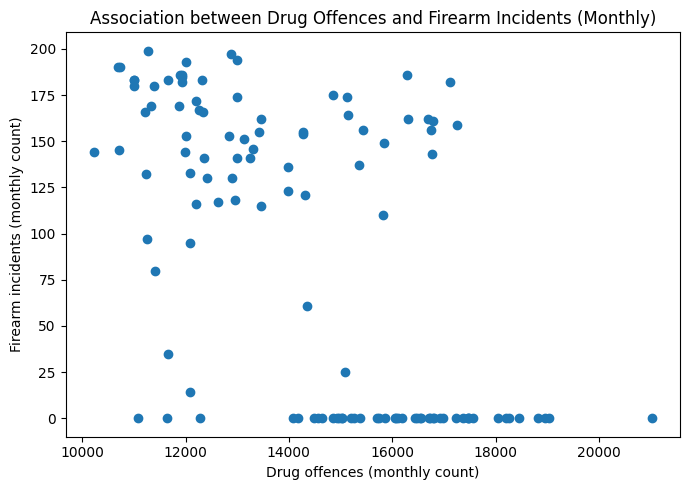

In [22]:
# Plotting the relationship between drug offences and firearms incidents

# Converting to pandas for plotting 
mnth_pd = fire_drg_month.select(
    "Firearm incidents",
    "Drug offences"
).toPandas()

# Scatterplot to show association between crimes 
plt.figure(figsize=(7, 5))
plt.scatter(
    mnth_pd["Drug offences"],
    mnth_pd["Firearm incidents"]
)

plt.xlabel("Drug offences (monthly count)")
plt.ylabel("Firearm incidents (monthly count)")
plt.title("Association between Drug Offences and Firearm Incidents (Monthly)")

plt.tight_layout()
plt.show()


PLOT INTERPRETATION

The scatter diagram compares the relationship between the number of drug offences and firearm incidents per month over the course of the study.
The plot shows the points spread widely suggesting high variation between the months. Within a few months, the number of firearm incidents is very low/zero, whereas there are higher levels of firearm incidents in months where there is a moderate level of drug offence. 
In general, the distribution does not suggest a strong positive association, it instead shows a mixed trend where increased drug offence counts could be associated with reduced firearm incidents in some months. The visual representation is not clear enough to define the relationship. It encourages the use of formal statistical methods to measure the direction and strength of the overall relationship. 


# 5) Selection, application, and reasoning behind use of statistical analysis and multiple evaluation measures

STATISTICAL ANALYSIS

Pearson correlation coefficient was chosen to assess numerically the relationship between firearm incidents and crime involving drugs. Pearson correlation is a measure that is used to determine the strength and direction of a linear relationship between two variables [10]. The count of firearm incidents and drug offences per month was summed up and time matched to allow a valid comparison.
The Pearson correlation was selected as a formal examination of the correlation proposed by the scatter plot in the section above. The aim of using the Pearson correlation test is only to measure the strength of the relationship between the variables and not to determine causation.


In [23]:
# Calculating pearson's correlation value 
pearsn_corr = fire_drg_month.stat.corr(
    "Firearm incidents",
    "Drug offences"
)

print("Pearson correlation:", pearsn_corr)


Pearson correlation: -0.5920181085219874


INTERPRETATION OF STATISTICAL RESULT

The correlation coefficient calculated was -0.59, which showed that there was a moderate negative linear relationship between monthly firearm incidents and drug offences during the period of the study. This implies that, the higher the number of drug offences in months, the lower the number of firearm incidents tends to be and vice versa, although the relationship is not exactly strong.
The magnitude of the coefficient shows a moderate correlation besides also showing high variability between months. This numerical finding can be seen as a quantitative justification of the relationship displayed in the scatter plot. Nevertheless, Pearson correlation has its  own limitations as it does not consider other external influencing factors and does not suggest causality. 


# 6) Detailed Analysis and consideration of the appropriateness of the solution for the initial problem


In Claim 1, the monthly time-series aggregation proved appropriate to determine the long-term trends of burglaries and minimize the effects of short-term changes. The use of rolling mean enhanced the interpretability by removing noise and bringing out underlying trends without distorting the original data [8]. The limitation of this approach is monthly aggregation could make short term changes less noticeable. These changes would otherwise be detected if smaller time units were used.

In Claim 2, the population had to be normalised by using per-head rates in order to facilitate a fair comparison between cities of varying population sizes, which is a common practice in crime analysis reporting [11]. Combining population data at LSOA level to city level provided consistency between crime data and population data. One drawback of this method is that it is sensitive to the size of the population so when the resident population of a particular location is very small, e.g. the City of London, per-head rates can be sensitive, with only a few incidents causing a high rate. It is important to view these ranked per head results in the context of the city’s characteristics and population instead of viewing them as objective measures of crime prevalence.  

Pearson correlation was applied to estimate the relationship between firearm incidents and drug offences in claim 3. The observed correlation was negative and moderate. Although Pearson correlation is suitable to quantify linear relationships between numeric variables, it fails to quantify non-linear relationships and other extraneous factors [10]. Pearson’s correlation relies on measurement scale assumptions, linearity assumptions, outlier assumptions, and normality assumptions. The monthly aggregation and the existence of months in which there are no firearm incidents can affect the observed correlation. Therefore, the Pearson correlation is a descriptive statistic of relationship, which is interpreted with care and not used as a foundation of statistical significance testing.

One of the strengths of the overall method is the application of Apache Spark to process data on a large scale. Spark allows processing large volumes of data in an efficient way, and allows the use of aggregation and joining operations to be performed with a great degree of stability, which is critical in analysing crime data on a national level [13]. The techniques used fail to measure the possible characteristics of confounding variables like socio-economic status that are known to affect crime rates [12]. Although there are limitations, the analytical method is suitable to the problem presented. The applied methods are clear, relevant, and appropriate to the claims under investigation.


# 7) Evaluation and Conclusion

This experiment tested three crime-related arguments based on large-scale UK crime data handled by Apache Spark. The analysis involved a combination of visualisations, population normalisation, and statistical analysis to evaluate the trends and associations between the relevant variables. 
In the case of Claim 1 (burglary crime is continuously rising), the time-series analysis of the occurrences of burglary fails to back the claim that burglary has been on the rise. The raw monthly counts as well as the rolling mean show general negative dynamics throughout the study period, with a sharp decrease starting in 2019. Although there are short term changes and intermittent phases of stabilisation, there is no long term upward trend in burglary offences.

Also, Claim 2 (There are more firearm incidents per head in Liverpool than anywhere else in the UK) compared firearm incidents per head between cities in the UK by using population-normalised rates based on population data at LSOAs aggregated to City. The ranked comparison reveals that Liverpool is not featured in the list of the top-ranked cities in this distribution, which means that it does not have the largest number of firearm incidences per head in the UK. Consequently, this claim is untrue.

Furthermore, In Claim 3 (crimes involving firearms are closely associated with drug offences), scatterplot of drug offences in relation to firearm incidents, as well as the Pearson’s correlation coefficient were used.The result shows a moderate negative relationship between the two types of crime. This result does not support the claim made. 
In conclusion, the analysis indicates that all of the three claims cannot be justified by the existing evidence. The result shows the importance of normalising population, appropriate aggregation techniques and careful interpretation of statistical association in big data analysis. Althoug the methods used are appropriate in determining patterns and relationships, the conclusion is ppurposely restricted to descriptive assessment and not causal inferences.


# 8) References and Citation 

[1] World Health Organization, *World Report on Violence*. Geneva, Switzerland: WHO Press, 2002.

[2] Ministry of Justice, “Youth justice statistics: 2021 to 2022,”  GOV.UK, 2022. [Online]. Available:https://www.gov.uk/government/statistics/youth-justice-statistics-2021-to-2022/youth-justice-statistics-2021-to-2022-accessible-version

[3] S. Y. M. Gillani, H. U. Rehman, and A. R. Gill, “Unemployment, poverty, inflation and crime nexus: Cointegration and causality analysis of Pakistan,” *Pakistan Economic and Social Review*, vol. 47, pp. 79–98, 2009.

[4] J. Arellana, M. Saltarín, A. M. Larrañaga, V. Alvarez, and C. A. Henao, “Urban walkability considering pedestrians’ perceptions of the built environment: A 10-year review and a case study in a medium-sized city in Latin America,” *Transport Reviews*, vol. 40, no. 2, pp. 183–203, 2020.

[5] V. Ceccato and J. Westman, “Where does firearm-related violence occur in cities?” *Journal of Planning Literature*, vol. 39, no. 3, pp. 347–364, 2024.doi: 10.1177/08854122231219918.

[6] I. R. Brennan, “Weapon-carrying and the reduction of violent harm,” *The British Journal of Criminology*, vol. 59, no. 3, pp. 571–593, May 2019. doi: 10.1093/bjc/azy032.

[7] Y. Wang, F. Han, L. Zhu, O. Deussen, and B. Chen, “Line graph or scatter plot? Automatic selection of methods for visualizing trends in time series,” *IEEE Transactions on Visualization and Computer Graphics*, vol. 23, no. 1, pp. 1–10, 2017.doi: 10.1109/TVCG.2017.2653106.

[8] A. Eckner, “Algorithms for unevenly-spaced time series: Moving averages and other rolling operators,” Working Paper, 2012.

[9] J. Li, J. B. Martens, and J. J. van Wijk, “Judging correlation from scatterplots and parallel coordinate plots,” *Information Visualization*, vol. 9, no. 1, pp. 13–30, 2010.

[10] S. Sreedevi, “Study of test for significance of Pearson’s correlation coefficient,” *Peer Reviewed Refereed Journal*, vol. 11, no. 2, p. 11, 2022.

[11] H. Wang, D. Kifer, C. Graif, and Z. Li, “Crime rate inference with big data,” in *Proc. 22nd ACM SIGKDD Int. Conf. on Knowledge Discovery and Data Mining*, San Francisco, CA, USA, Aug. 2016, pp. 635–644.

[12] J. M. Bothos and S. C. Thomopoulos, “Factors influencing crime rates: An econometric analysis approach,” in *Signal Processing, Sensor/Information Fusion, and Target Recognition XXV*, vol. 9842, SPIE, May 2016, pp. 467–476.

[13] V. S. Jonnalagadda, P. Srikanth, K. Thumati, S. H. Nallamala, and K. Dist, “A review study of Apache Spark in big data processing,” International Journal of Computer Science Trends and Technology (IJCST), vol. 4, no. 3, pp. 93–98, 2016.
